# Análisis de Varianza (ANOVA) e Introducción al PCA

Este notebook introduce el **Análisis de Varianza (ANOVA)** como herramienta para comparar grupos y descomponer la variabilidad total de un conjunto de datos. A partir de esa base conceptual, se establece un puente natural hacia el **Análisis de Componentes Principales (PCA)**, que extiende la descomposición de la varianza al espacio multivariado.

## Objetivos
- Comprender la lógica de descomposición de varianza: total = entre grupos + dentro de grupos.
- Ejecutar e interpretar una ANOVA de un factor y de dos factores.
- Verificar los supuestos de ANOVA (normalidad, homocedasticidad, independencia).
- Entender cómo PCA generaliza la idea de «maximizar varianza explicada».
- Conectar el escree plot y la varianza explicada del PCA con la tabla ANOVA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, levene, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(2025)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Parte 1 — Análisis de Varianza (ANOVA)

### 1.1 Motivación: ¿Por qué no usar múltiples t-tests?

Cuando queremos comparar las medias de **tres o más grupos**, aplicar un t-test para cada par de grupos infla el error de tipo I (falsos positivos). Si tenemos $k$ grupos y nivel de significancia $\alpha$, la probabilidad de cometer al menos un error es:


$$ P(\text{al menos un error}) = 1 - (1-\alpha)^{\binom{k}{2}} $$

Con $k = 4$ grupos y $\alpha = 0.05$:


$$ P = 1 - (0.95)^{6} \approx 0.26 \quad \text{(¡26% de error global!)} $$


La ANOVA resuelve este problema comparando todos los grupos **simultáneamente** con una única prueba.

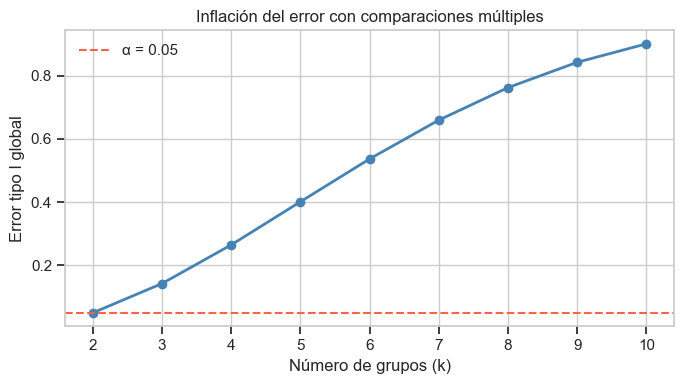

In [2]:
# Ilustración del problema de comparaciones múltiples
k_values = np.arange(2, 11)
alpha = 0.05
error_global = [1 - (1 - alpha) ** (k * (k-1) // 2) for k in k_values]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, error_global, marker='o', color='steelblue', linewidth=2)
ax.axhline(0.05, color='tomato', linestyle='--', label='α = 0.05')
ax.set_xlabel('Número de grupos (k)')
ax.set_ylabel('Error tipo I global')
ax.set_title('Inflación del error con comparaciones múltiples')
ax.legend()
plt.tight_layout()
plt.show()

### 1.2 Descomposición de la varianza total

La idea central de ANOVA es descomponer la **suma de cuadrados total (SCT)** en dos partes:

$$\underbrace{\sum_{i=1}^{k}\sum_{j=1}^{n_i}(y_{ij} - \bar{y})^2}_{\text{SCT}} = \underbrace{\sum_{i=1}^{k} n_i(\bar{y}_i - \bar{y})^2}_{\text{SCE (entre grupos)}} + \underbrace{\sum_{i=1}^{k}\sum_{j=1}^{n_i}(y_{ij} - \bar{y}_i)^2}_{\text{SCD (dentro de grupos)}}
$$

| Fuente | SC | gl | CM | F |
|---|---|---|---|---|
| Entre grupos | SCE | $k-1$ | $\text{CME} = \frac{\text{SCE}}{k-1}$ | $F = \frac{\text{CME}}{\text{CMD}}$ |
| Dentro de grupos | SCD | $N-k$ | $\text{CMD} = \frac{\text{SCD}}{N-k}$ | — |
| Total | SCT | $N-1$ | — | — |

Si $H_0$ es verdadera (todas las medias son iguales), ambos cuadrados medios (CME y CMD) estiman la misma varianza poblacional $\sigma^2$, por lo que $F \approx 1$. Un $F$ grande indica que la variabilidad **entre grupos** es mayor de lo esperado por azar.

### 1.3 Datos de ejemplo: rendimiento de fertilizantes

Se tienen cuatro tratamientos de fertilizante (A, B, C, D) aplicados a parcelas agrícolas. La variable respuesta es el **rendimiento en kg/ha**.

In [3]:
# Generación de datos sintéticos
n_por_grupo = 20
grupos = {
    'A': np.random.normal(4200, 300, n_por_grupo),
    'B': np.random.normal(4600, 280, n_por_grupo),
    'C': np.random.normal(4400, 320, n_por_grupo),
    'D': np.random.normal(5000, 310, n_por_grupo),
}

df = pd.DataFrame({
    'rendimiento': np.concatenate(list(grupos.values())),
    'fertilizante': np.repeat(list(grupos.keys()), n_por_grupo)
})

print(df.groupby('fertilizante')['rendimiento'].describe().round(1))

              count    mean    std     min     25%     50%     75%     max
fertilizante                                                              
A              20.0  4180.6  288.6  3663.2  3988.6  4171.0  4301.2  4844.1
B              20.0  4621.3  202.3  4247.4  4538.6  4607.8  4774.6  5044.9
C              20.0  4408.1  350.2  3954.2  4057.3  4357.4  4710.3  5008.5
D              20.0  4894.5  301.3  4516.1  4673.3  4810.3  5085.4  5474.5


/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_25465/369937644.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fertilizante', y='rendimiento', palette='Set2', ax=ax)


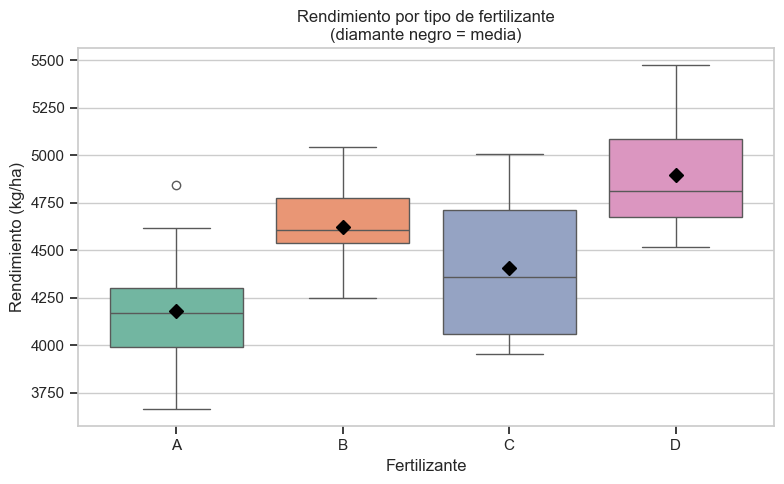

In [4]:
# Diagrama de caja con media señalada
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='fertilizante', y='rendimiento', palette='Set2', ax=ax)
# Añadir medias
medias = df.groupby('fertilizante')['rendimiento'].mean()
for i, (grupo, m) in enumerate(medias.items()):
    ax.plot(i, m, marker='D', color='black', markersize=7, zorder=5)
ax.set_title('Rendimiento por tipo de fertilizante\n(diamante negro = media)')
ax.set_xlabel('Fertilizante')
ax.set_ylabel('Rendimiento (kg/ha)')
plt.tight_layout()
plt.show()

### 1.4 Verificación de supuestos

La ANOVA clásica requiere:
1. **Normalidad** de los residuos (por grupo).
2. **Homocedasticidad**: varianzas iguales en todos los grupos (prueba de Levene).
3. **Independencia** de las observaciones (diseño experimental).

In [5]:
# --- Normalidad: Shapiro-Wilk por grupo ---
print('Prueba Shapiro-Wilk (H0: distribución normal)')
print('-' * 45)
for g, datos in grupos.items():
    stat, p = shapiro(datos)
    resultado = 'No se rechaza H0' if p > 0.05 else 'SE RECHAZA H0'
    print(f'  Grupo {g}: W={stat:.4f}, p={p:.4f}  →  {resultado}')

print()
# --- Homocedasticidad: Levene ---
stat_lev, p_lev = levene(*grupos.values())
resultado_lev = 'No se rechaza H0' if p_lev > 0.05 else 'SE RECHAZA H0'
print(f'Prueba de Levene (H0: varianzas iguales)')
print(f'  W={stat_lev:.4f}, p={p_lev:.4f}  →  {resultado_lev}')

Prueba Shapiro-Wilk (H0: distribución normal)
---------------------------------------------
  Grupo A: W=0.9753, p=0.8601  →  No se rechaza H0
  Grupo B: W=0.9756, p=0.8649  →  No se rechaza H0
  Grupo C: W=0.9007, p=0.0424  →  SE RECHAZA H0
  Grupo D: W=0.9196, p=0.0975  →  No se rechaza H0

Prueba de Levene (H0: varianzas iguales)
  W=3.1944, p=0.0282  →  SE RECHAZA H0


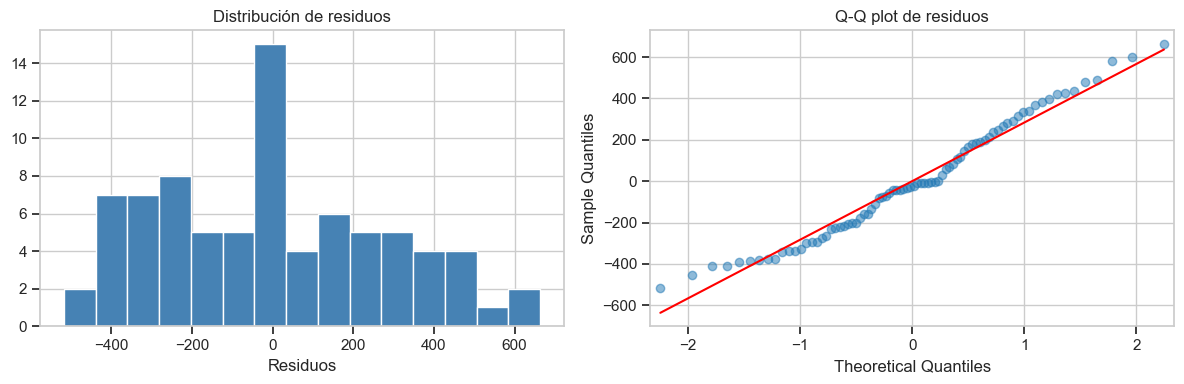

In [6]:
# Gráfico Q-Q de residuos globales
modelo_ols = smf.ols('rendimiento ~ C(fertilizante)', data=df).fit()
residuos = modelo_ols.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(residuos, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de residuos')
axes[0].set_xlabel('Residuos')

# Q-Q plot
sm.qqplot(residuos, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Q-Q plot de residuos')

plt.tight_layout()
plt.show()

### 1.5 ANOVA de un factor (one-way)

Con los supuestos verificados procedemos a realizar la prueba.

In [7]:
# ANOVA con scipy
F, p_valor = f_oneway(*grupos.values())
print(f'F = {F:.4f},  p-valor = {p_valor:.6f}')
print('Conclusión:', 'Hay diferencias significativas entre grupos (α=0.05)' if p_valor < 0.05
      else 'No hay evidencia de diferencias significativas')

print()
# Tabla ANOVA completa con statsmodels
tabla_anova = sm.stats.anova_lm(modelo_ols, typ=1)
print(tabla_anova.round(4))

F = 21.9647,  p-valor = 0.000000
Conclusión: Hay diferencias significativas entre grupos (α=0.05)

                   df        sum_sq       mean_sq        F  PR(>F)
C(fertilizante)   3.0  5.562009e+06  1.854003e+06  21.9647     0.0
Residual         76.0  6.415031e+06  8.440831e+04      NaN     NaN


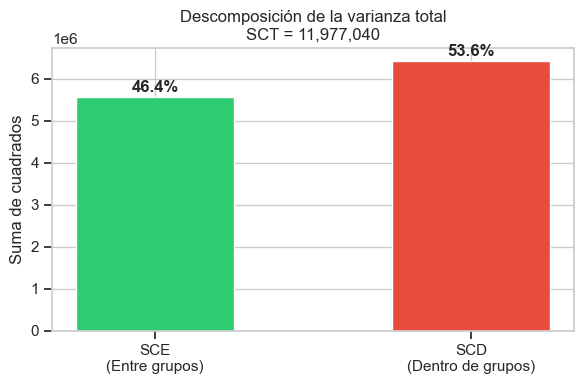

In [8]:
# Descomposición visual de la varianza
SCT = ((df['rendimiento'] - df['rendimiento'].mean()) ** 2).sum()
SCE = sum(n_por_grupo * (m - df['rendimiento'].mean()) ** 2 for m in medias)
SCD = SCT - SCE

fig, ax = plt.subplots(figsize=(6, 4))
etiquetas = ['SCE\n(Entre grupos)', 'SCD\n(Dentro de grupos)']
valores = [SCE, SCD]
colores = ['#2ecc71', '#e74c3c']
bars = ax.bar(etiquetas, valores, color=colores, edgecolor='white', width=0.5)
for bar, v in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + SCT*0.01,
            f'{v/SCT:.1%}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Suma de cuadrados')
ax.set_title(f'Descomposición de la varianza total\nSCT = {SCT:,.0f}')
plt.tight_layout()
plt.show()

### 1.6 Comparaciones múltiples: prueba de Tukey HSD

La ANOVA nos dice **si** hay diferencias, pero no **entre cuáles** grupos. La prueba de Tukey controla el error familiar manteniendo $\alpha$ constante.

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     A      B  440.7052    0.0  199.3709 682.0395   True
     A      C  227.5352 0.0718  -13.7991 468.8695  False
     A      D  713.9433    0.0   472.609 955.2776   True
     B      C -213.1699 0.1024 -454.5043  28.1644  False
     B      D  273.2381 0.0201   31.9038 514.5724   True
     C      D  486.4081    0.0  245.0738 727.7424   True
--------------------------------------------------------


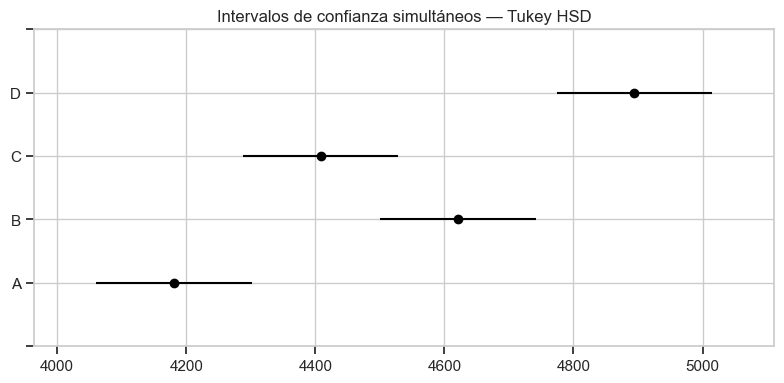

In [9]:
tukey = pairwise_tukeyhsd(df['rendimiento'], df['fertilizante'], alpha=0.05)
print(tukey)

# Visualización
fig = tukey.plot_simultaneous(figsize=(8, 4))
plt.title('Intervalos de confianza simultáneos — Tukey HSD')
plt.tight_layout()
plt.show()

### 1.7 ANOVA de dos factores

Cuando hay **dos factores** de tratamiento (p.ej., fertilizante × riego) también podemos estudiar su **interacción**.

El modelo es:
$$y_{ijk} = \mu + \alpha_i + \beta_j + (\alpha\beta)_{ij} + \varepsilon_{ijk}$$

Generamos datos donde hay efecto de fertilizante, de riego y una leve interacción.

In [10]:
# Datos dos factores: fertilizante (A,B,C,D) × riego (bajo, alto)
recs = []
efectos_fertil = {'A': 0, 'B': 400, 'C': 200, 'D': 800}
efectos_riego  = {'bajo': 0, 'alto': 300}
interaccion    = {('B', 'alto'): 200, ('D', 'bajo'): -150}  # interacciones específicas

for fert, ef in efectos_fertil.items():
    for riego, er in efectos_riego.items():
        inter = interaccion.get((fert, riego), 0)
        mu_ij = 4200 + ef + er + inter
        y = np.random.normal(mu_ij, 280, 15)
        for yi in y:
            recs.append({'rendimiento': yi, 'fertilizante': fert, 'riego': riego})

df2 = pd.DataFrame(recs)

# Tabla de medias
print(df2.groupby(['fertilizante', 'riego'])['rendimiento'].mean().unstack().round(1))

riego           alto    bajo
fertilizante                
A             4506.5  4093.3
B             5091.7  4619.6
C             4739.9  4347.0
D             5370.0  4855.0


In [11]:
# ANOVA de dos factores con interacción
modelo2 = smf.ols('rendimiento ~ C(fertilizante) * C(riego)', data=df2).fit()
tabla2 = sm.stats.anova_lm(modelo2, typ=2)
print(tabla2.round(4))

                                sum_sq     df        F  PR(>F)
C(fertilizante)           1.136705e+07    3.0  50.3741  0.0000
C(riego)                  6.029615e+06    1.0  80.1624  0.0000
C(fertilizante):C(riego)  6.977711e+04    3.0   0.3092  0.8187
Residual                  8.424358e+06  112.0      NaN     NaN


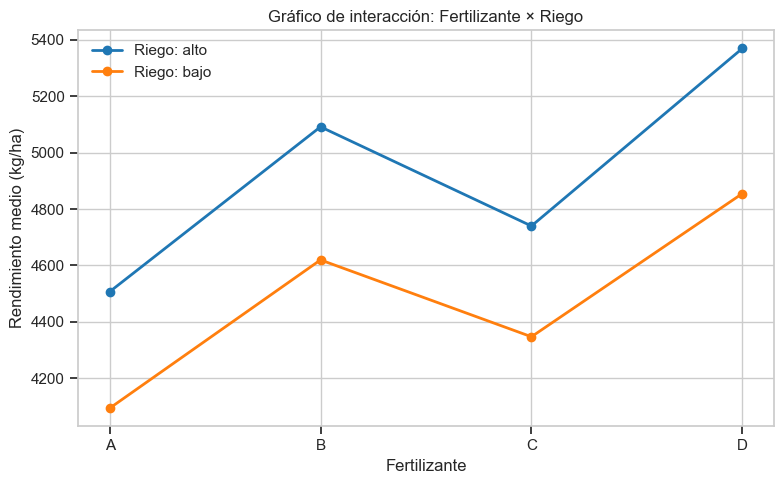

In [12]:
# Gráfico de interacción
medias2 = df2.groupby(['fertilizante', 'riego'])['rendimiento'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
for riego, sub in medias2.groupby('riego'):
    ax.plot(sub['fertilizante'], sub['rendimiento'], marker='o',
            linewidth=2, label=f'Riego: {riego}')
ax.set_title('Gráfico de interacción: Fertilizante × Riego')
ax.set_xlabel('Fertilizante')
ax.set_ylabel('Rendimiento medio (kg/ha)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Parte 2 — Del ANOVA al PCA: la varianza como hilo conductor

### 2.1 El concepto clave: maximizar varianza explicada

Tanto en ANOVA como en PCA el objetivo es **entender la variabilidad** de los datos:

| Aspecto | ANOVA | PCA |
|---|---|---|
| Pregunta | ¿Los grupos explican la varianza? | ¿Qué combinación lineal explica la máxima varianza? |
| Descomposición | SCT = SCE + SCD | $\text{Var total} = \lambda_1 + \lambda_2 + ... + \lambda_p$ |
| Resultado | Razón F, p-valor | Componentes principales, eigenvalores |
| Dimensión | 1 variable respuesta, $k$ grupos | $p$ variables, sin etiquetas de grupo |

> **Idea central del PCA**: en lugar de asignar varianza a factores discretos (como ANOVA), PCA encuentra las **direcciones** en el espacio $p$-dimensional a lo largo de las cuales los datos varían más.

### 2.2 Fundamentos matemáticos del PCA

Dado un conjunto de datos $\mathbf{X}$ de $n$ observaciones y $p$ variables (estandarizadas), PCA busca una matrix ortogonal $\mathbf{W}$ tal que las **componentes principales** $\mathbf{Z} = \mathbf{X}\mathbf{W}$ tengan varianza máxima y sean no correlacionadas.

Esto equivale a la **descomposición espectral** de la matriz de correlaciones $\mathbf{R}$:

$$\mathbf{R} = \mathbf{W}\boldsymbol{\Lambda}\mathbf{W}^T$$

donde $\boldsymbol{\Lambda} = \text{diag}(\lambda_1, \lambda_2, ..., \lambda_p)$ con $\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_p \geq 0$.

**Proporción de varianza explicada** por el componente $j$:
$$PVE_j = \frac{\lambda_j}{\sum_{i=1}^{p}\lambda_i}$$

**Analogía con ANOVA**:  
$$\underbrace{\frac{\lambda_j}{\sum \lambda_i}}_{\text{PCA}} \longleftrightarrow \underbrace{\frac{\text{SCE}}{\text{SCT}}}_{\text{ANOVA}} = \eta^2 \quad (\text{eta cuadrado})$$

In [13]:
# Dataset multivariado sintético con estructura grupal
n = 150
# 3 grupos con medias distintas en 5 variables
mu1 = [2, 3, 1, 4, 2]
mu2 = [5, 1, 4, 2, 5]
mu3 = [1, 5, 3, 1, 3]
cov = np.array([
    [1.0, 0.8, 0.3, 0.1, 0.5],
    [0.8, 1.0, 0.2, 0.3, 0.4],
    [0.3, 0.2, 1.0, 0.6, 0.1],
    [0.1, 0.3, 0.6, 1.0, 0.2],
    [0.5, 0.4, 0.1, 0.2, 1.0]
])

X1 = np.random.multivariate_normal(mu1, cov, n // 3)
X2 = np.random.multivariate_normal(mu2, cov, n // 3)
X3 = np.random.multivariate_normal(mu3, cov, n // 3)
X_all = np.vstack([X1, X2, X3])
grupos_mv = ['G1'] * (n//3) + ['G2'] * (n//3) + ['G3'] * (n//3)

cols = [f'X{i+1}' for i in range(5)]
df_mv = pd.DataFrame(X_all, columns=cols)
df_mv['grupo'] = grupos_mv
df_mv.head()

,X1,X2,X3,X4,X5,grupo
0,2.087519,3.420718,0.715096,4.128921,3.807069,G1
1,0.494049,2.763264,-0.401684,4.362654,0.538161,G1
2,0.556143,2.386792,0.857475,4.876457,1.788052,G1
3,2.700133,4.209574,2.304524,5.018981,1.254984,G1
4,2.986979,3.626069,1.480506,3.674703,1.114570,G1


### 2.3 ANOVA univariado para cada variable

Antes de PCA, comprobemos qué variables discriminan significativamente entre grupos.

In [14]:
resultados_anova = []
for col in cols:
    g1 = df_mv.loc[df_mv['grupo']=='G1', col]
    g2 = df_mv.loc[df_mv['grupo']=='G2', col]
    g3 = df_mv.loc[df_mv['grupo']=='G3', col]
    F, p = f_oneway(g1, g2, g3)
    # eta cuadrado
    grand_mean = df_mv[col].mean()
    sce = sum(len(g) * (g.mean() - grand_mean)**2 for g in [g1,g2,g3])
    sct = ((df_mv[col] - grand_mean)**2).sum()
    eta2 = sce / sct
    resultados_anova.append({'Variable': col, 'F': round(F,3), 'p-valor': round(p,4),
                              'η²': round(eta2, 3),
                              'Significativa': 'Sí' if p < 0.05 else 'No'})

df_anova_mv = pd.DataFrame(resultados_anova).set_index('Variable')
print(df_anova_mv)

                F  p-valor     η² Significativa
Variable                                       
X1        239.399      0.0  0.765            Sí
X2        241.881      0.0  0.767            Sí
X3        127.133      0.0  0.634            Sí
X4        135.907      0.0  0.649            Sí
X5        117.129      0.0  0.614            Sí


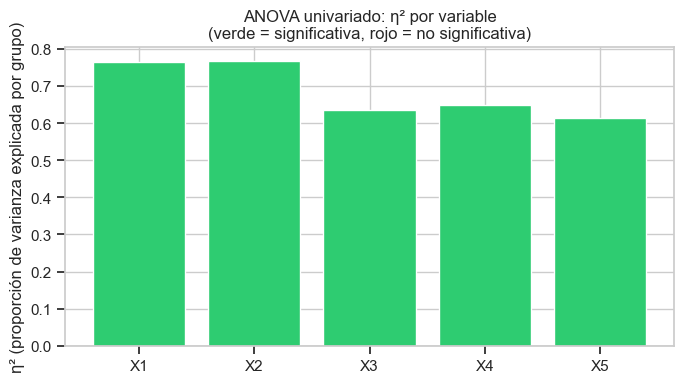

In [15]:
# Visualizar η² por variable
fig, ax = plt.subplots(figsize=(7, 4))
colores_bar = ['#2ecc71' if s == 'Sí' else '#e74c3c'
               for s in df_anova_mv['Significativa']]
ax.bar(df_anova_mv.index, df_anova_mv['η²'], color=colores_bar, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('η² (proporción de varianza explicada por grupo)')
ax.set_title('ANOVA univariado: η² por variable\n(verde = significativa, rojo = no significativa)')
plt.tight_layout()
plt.show()

### 2.4 Aplicación de PCA

Ahora aplicamos PCA al mismo conjunto de datos y analizamos cuánta varianza **total** captura cada componente.

In [16]:
# Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(df_mv[cols])

# PCA
pca = PCA()
Z = pca.fit_transform(X_std)

# Eigenvalores (varianza de cada componente)
eigenvalores = pca.explained_variance_
pve = pca.explained_variance_ratio_
pve_acum = np.cumsum(pve)

tabla_pca = pd.DataFrame({
    'Eigenvalor (λ)': eigenvalores.round(3),
    'PVE (%)': (pve * 100).round(2),
    'PVE Acumulado (%)': (pve_acum * 100).round(2)
}, index=[f'PC{i+1}' for i in range(len(eigenvalores))])
print(tabla_pca)

     Eigenvalor (λ)  PVE (%)  PVE Acumulado (%)
PC1           2.469    49.06              49.06
PC2           1.327    26.37              75.43
PC3           0.536    10.65              86.08
PC4           0.482     9.58              95.65
PC5           0.219     4.35             100.00


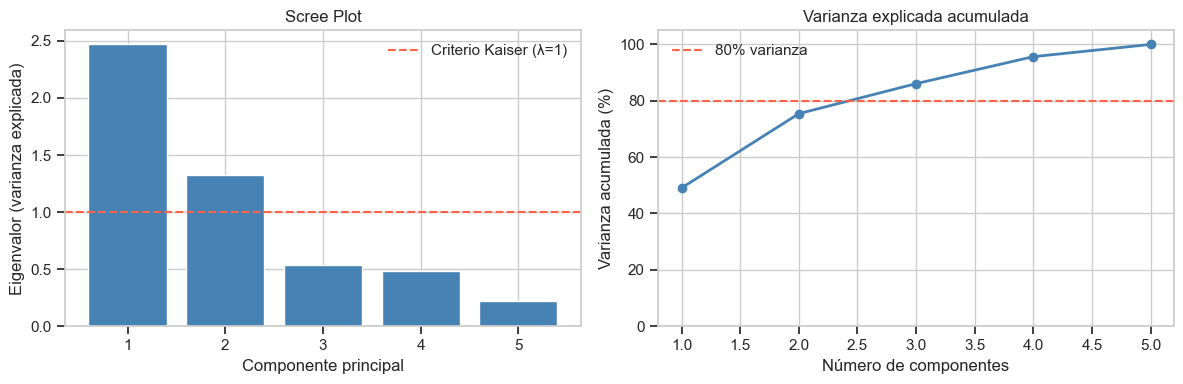

In [17]:
# Scree plot + varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, len(eigenvalores)+1), eigenvalores, color='steelblue', edgecolor='white')
axes[0].axhline(1, color='tomato', linestyle='--', label='Criterio Kaiser (λ=1)')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Eigenvalor (varianza explicada)')
axes[0].set_title('Scree Plot')
axes[0].legend()

# Varianza acumulada
axes[1].plot(range(1, len(pve_acum)+1), pve_acum * 100, marker='o', color='steelblue', linewidth=2)
axes[1].axhline(80, color='tomato', linestyle='--', label='80% varianza')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza explicada acumulada')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

### 2.5 Cargas del PCA (loadings)

Las cargas ($\mathbf{W}$) indican qué tanto contribuye cada variable original a cada componente.

$$w_{jk} = \text{correlación entre la variable } X_j \text{ y el componente } PC_k$$

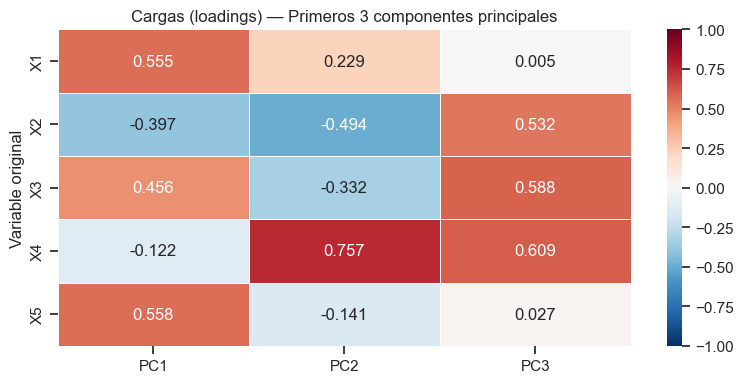

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=cols,
    columns=[f'PC{i+1}' for i in range(len(eigenvalores))]
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(loadings.iloc[:, :3], annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Cargas (loadings) — Primeros 3 componentes principales')
ax.set_ylabel('Variable original')
plt.tight_layout()
plt.show()

### 2.6 Biplot: scores + loadings 

El biplot proyecta las observaciones (scores) y las variables (loadings) en el plano PC1–PC2 simultáneamente.

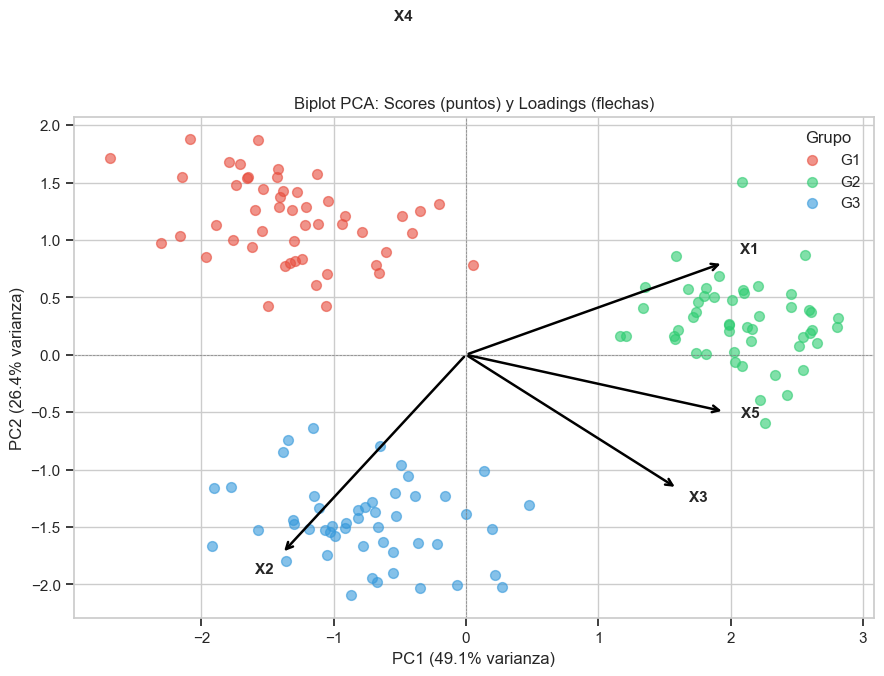

In [19]:
scores = Z[:, :2]  # PC1 y PC2
load2d = pca.components_[:2].T  # cargas de las 2 primeras CP

colores_grupo = {'G1': '#e74c3c', 'G2': '#2ecc71', 'G3': '#3498db'}

fig, ax = plt.subplots(figsize=(9, 7))

for g, color in colores_grupo.items():
    mask = np.array(grupos_mv) == g
    ax.scatter(scores[mask, 0], scores[mask, 1],
               c=color, label=g, alpha=0.6, s=50)

# Flechas de cargas (escaladas)
escala = 3.5
for i, var in enumerate(cols):
    ax.annotate('', xy=(load2d[i, 0]*escala, load2d[i, 1]*escala),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.8))
    ax.text(load2d[i, 0]*escala*1.1, load2d[i, 1]*escala*1.1,
            var, fontsize=11, fontweight='bold', ha='center')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pve[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pve[1]*100:.1f}% varianza)')
ax.set_title('Biplot PCA: Scores (puntos) y Loadings (flechas)')
ax.legend(title='Grupo')
plt.tight_layout()
plt.show()

### 2.7 Relación ANOVA sobre componentes principales

Una vez obtenidas las componentes, podemos aplicar ANOVA sobre ellas para saber cuáles discriminan entre grupos. Esto es especialmente útil cuando los grupos son conocidos.

In [20]:
# ANOVA de cada CP con respecto a los grupos
df_scores = pd.DataFrame(Z, columns=[f'PC{i+1}' for i in range(Z.shape[1])])
df_scores['grupo'] = grupos_mv

res_pca_anova = []
for pc in [f'PC{i+1}' for i in range(5)]:
    g1 = df_scores.loc[df_scores['grupo']=='G1', pc]
    g2 = df_scores.loc[df_scores['grupo']=='G2', pc]
    g3 = df_scores.loc[df_scores['grupo']=='G3', pc]
    F, p = f_oneway(g1, g2, g3)
    grand = df_scores[pc].mean()
    sce = sum(len(g)*(g.mean()-grand)**2 for g in [g1,g2,g3])
    sct = ((df_scores[pc]-grand)**2).sum()
    eta2 = sce/sct
    res_pca_anova.append({'Componente': pc, 'F': round(F,3),
                          'p-valor': round(p,4), 'η²': round(eta2,3)})

df_ra = pd.DataFrame(res_pca_anova).set_index('Componente')
print(df_ra)

                  F  p-valor     η²
Componente                         
PC1         632.621   0.0000  0.896
PC2         734.663   0.0000  0.909
PC3           2.226   0.1116  0.029
PC4           1.893   0.1543  0.025
PC5           1.820   0.1656  0.024


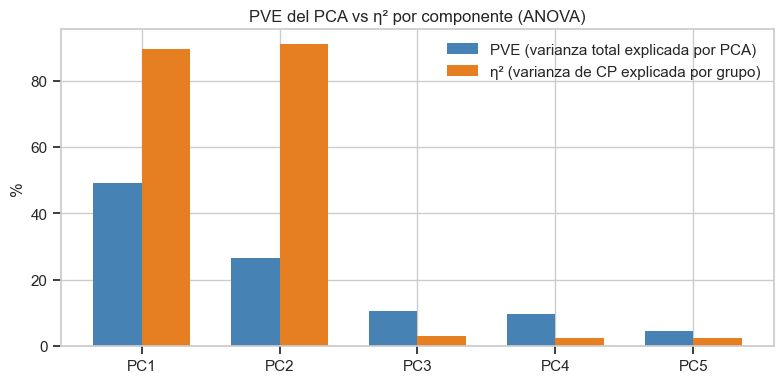

In [21]:
# Comparación: PVE del PCA vs η² sobre los componentes
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(5)
width = 0.35
ax.bar(x - width/2, pve * 100, width, label='PVE (varianza total explicada por PCA)', color='steelblue')
ax.bar(x + width/2, df_ra['η²'] * 100, width, label='η² (varianza de CP explicada por grupo)', color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels([f'PC{i+1}' for i in range(5)])
ax.set_ylabel('%')
ax.set_title('PVE del PCA vs η² por componente (ANOVA)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Parte 3 — Ejemplo con datos reales: Salarios del profesorado universitario

En esta sección aplicamos ANOVA y PCA a datos reales de contexto administrativo académico: **salarios de docentes universitarios en EE.UU.** (Fox & Weisberg, carData, 2011).

### Descripción del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `rank` | Categórica | Rango: AsstProf, AssocProf, Prof |
| `discipline` | Categórica | Disciplina: A (teórica), B (aplicada) |
| `yrs.since.phd` | Numérica | Años desde el doctorado |
| `yrs.service` | Numérica | Años de servicio en la institución |
| `sex` | Categórica | Sexo del docente |
| `salary` | Numérica | Salario anual en USD |

**Preguntas de gestión académica:**
1. ¿Existen diferencias significativas de salario entre rangos académicos?
2. ¿La disciplina y el rango interactúan sobre el salario?
3. ¿Qué estructura multivariada revelan las variables numéricas?

In [22]:
# Carga del dataset (requiere conexión sólo la primera vez; se almacena en caché)
import statsmodels.api as sm

ds = sm.datasets.get_rdataset('Salaries', 'carData')
sal = ds.data.rename(columns={'yrs.since.phd': 'yrs_phd', 'yrs.service': 'yrs_svc'})

# Orden categórico natural de los rangos
orden_rank = ['AsstProf', 'AssocProf', 'Prof']
sal['rank'] = pd.Categorical(sal['rank'], categories=orden_rank, ordered=True)

print(f'Observaciones: {sal.shape[0]}  |  Variables: {sal.shape[1]}')
print()
print(sal.groupby('rank')[['yrs_phd', 'yrs_svc', 'salary']].mean().round(1))

Observaciones: 397  |  Variables: 6

           yrs_phd  yrs_svc    salary
rank                                 
AsstProf       5.1      2.4   80776.0
AssocProf     15.5     12.0   93876.4
Prof          28.3     22.8  126772.1


/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_25465/1304113760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sal, x='rank', y='salary', palette=palette_r,
/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_25465/1304113760.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sal, x='discipline', y='salary', palette='Set2', ax=axes[1])


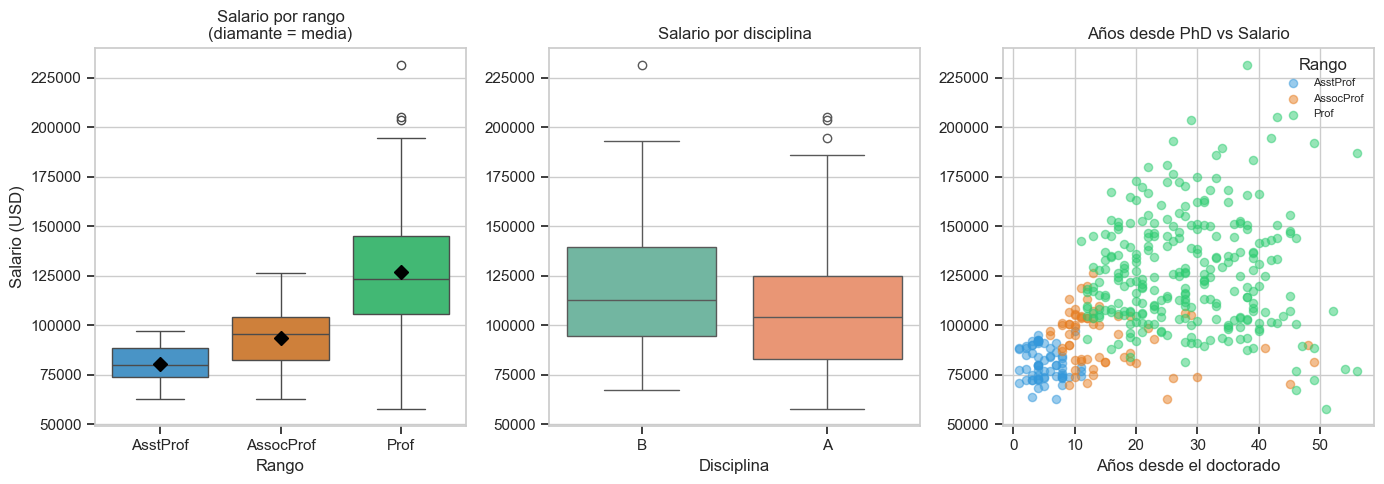

In [23]:
# Visualización exploratoria
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
palette_r = {'AsstProf': '#3498db', 'AssocProf': '#e67e22', 'Prof': '#2ecc71'}

# Distribución de salarios por rango
sns.boxplot(data=sal, x='rank', y='salary', palette=palette_r,
            order=orden_rank, ax=axes[0])
medias_rank = sal.groupby('rank')['salary'].mean()
for i, (r, m) in enumerate(medias_rank.items()):
    axes[0].plot(i, m, marker='D', color='black', markersize=7, zorder=5)
axes[0].set_title('Salario por rango\n(diamante = media)')
axes[0].set_ylabel('Salario (USD)')
axes[0].set_xlabel('Rango')

# Salario por disciplina
sns.boxplot(data=sal, x='discipline', y='salary', palette='Set2', ax=axes[1])
axes[1].set_title('Salario por disciplina')
axes[1].set_ylabel('')
axes[1].set_xlabel('Disciplina')

# Años desde PhD vs salario
for rk, sub in sal.groupby('rank'):
    axes[2].scatter(sub['yrs_phd'], sub['salary'], alpha=0.5,
                    label=rk, color=palette_r[rk], s=35)
axes[2].set_title('Años desde PhD vs Salario')
axes[2].set_xlabel('Años desde el doctorado')
axes[2].set_ylabel('')
axes[2].legend(title='Rango', fontsize=8)

plt.tight_layout()
plt.show()

### 3.1 ANOVA de un factor: ¿difieren los salarios por rango?

**Hipótesis:**
- $H_0$: $\mu_{AsstProf} = \mu_{AssocProf} = \mu_{Prof}$
- $H_1$: Al menos un par de medias difiere

In [24]:
# Supuestos: Shapiro-Wilk + Levene
print('Shapiro-Wilk por rango (H0: normalidad)')
print('-' * 45)
for rk in orden_rank:
    sub = sal.loc[sal['rank'] == rk, 'salary']
    stat, p = shapiro(sub)
    print(f'  {rk:12s}: W={stat:.4f}, p={p:.4f}  \u2192  '
          f'{"No se rechaza H0" if p > 0.05 else "SE RECHAZA H0"}')

grps_rank = [sal.loc[sal['rank']==r, 'salary'] for r in orden_rank]
stat_lev, p_lev = levene(*grps_rank)
print()
print(f'Levene (H0: varianzas iguales): W={stat_lev:.4f}, p={p_lev:.4f}  \u2192  '
      f'{"No se rechaza H0" if p_lev > 0.05 else "SE RECHAZA H0"}')

Shapiro-Wilk por rango (H0: normalidad)
---------------------------------------------
  AsstProf    : W=0.9600, p=0.0301  →  SE RECHAZA H0
  AssocProf   : W=0.9754, p=0.2290  →  No se rechaza H0
  Prof        : W=0.9760, p=0.0002  →  SE RECHAZA H0

Levene (H0: varianzas iguales): W=38.7111, p=0.0000  →  SE RECHAZA H0


In [25]:
# ANOVA one-way: salary ~ rank
modelo_rank = smf.ols('salary ~ C(rank)', data=sal).fit()
tabla_rank = sm.stats.anova_lm(modelo_rank, typ=1)
print('Tabla ANOVA \u2014 salario por rango')
print(tabla_rank.round(2))
print()

# Eta cuadrado
SCE_r = tabla_rank.loc['C(rank)', 'sum_sq']
SCT_r = tabla_rank['sum_sq'].sum()
eta2_rank = SCE_r / SCT_r
print(f'\u03b7\u00b2 = {eta2_rank:.4f}  ({eta2_rank*100:.1f}% de la varianza del salario explicada por el rango)')

Tabla ANOVA — salario por rango
             df        sum_sq       mean_sq       F  PR(>F)
C(rank)     2.0  1.432318e+11  7.161588e+10  128.22     0.0
Residual  394.0  2.200689e+11  5.585504e+08     NaN     NaN

η² = 0.3943  (39.4% de la varianza del salario explicada por el rango)


        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1   group2    meandiff  p-adj     lower      upper    reject
-------------------------------------------------------------------
AssocProf AsstProf -13100.4524 0.0047 -22818.7096 -3382.1952   True
AssocProf     Prof  32895.6715    0.0  25154.5071  40636.836   True
 AsstProf     Prof  45996.1239    0.0  38395.9413 53596.3066   True
-------------------------------------------------------------------


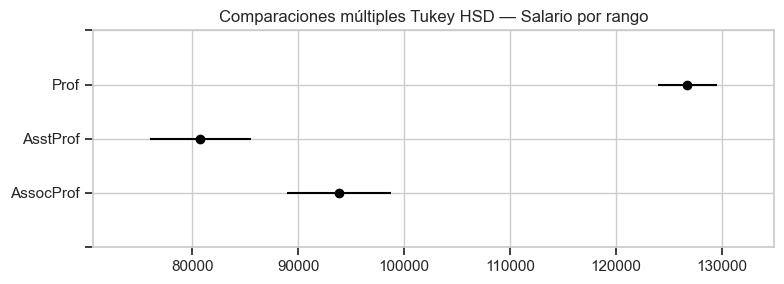

In [26]:
# Tukey HSD post-hoc
tukey_sal = pairwise_tukeyhsd(sal['salary'], sal['rank'], alpha=0.05)
print(tukey_sal)

fig = tukey_sal.plot_simultaneous(figsize=(8, 3))
plt.title('Comparaciones m\u00faltiples Tukey HSD \u2014 Salario por rango')
plt.tight_layout()
plt.show()

### 3.2 ANOVA de dos factores: rango × disciplina

Evaluamos si la disciplina (A vs B) también afecta el salario y si existe interacción.

Tabla ANOVA — salario ~ rango × disciplina
                             sum_sq     df       F  PR(>F)
C(rank)                1.528109e+11    2.0  148.50    0.00
C(discipline)          1.842993e+10    1.0   35.82    0.00
C(rank):C(discipline)  4.611825e+08    2.0    0.45    0.64
Residual               2.011778e+11  391.0     NaN     NaN


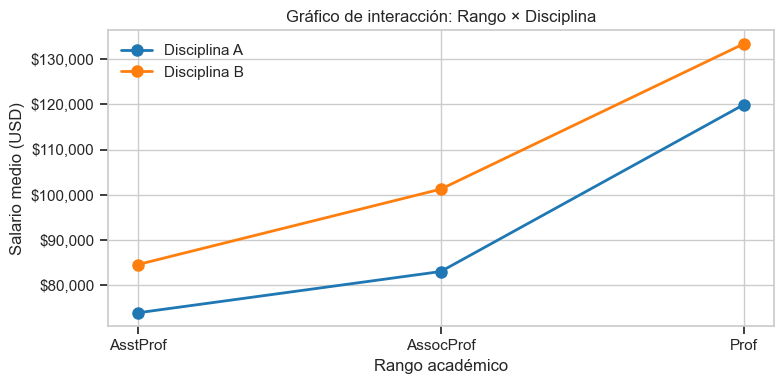

In [27]:
# ANOVA dos factores con interacción
modelo_2f = smf.ols('salary ~ C(rank) * C(discipline)', data=sal).fit()
tabla_2f = sm.stats.anova_lm(modelo_2f, typ=2)
print('Tabla ANOVA \u2014 salario ~ rango \u00d7 disciplina')
print(tabla_2f.round(2))

# Gr\u00e1fico de interacci\u00f3n
medias_2f = sal.groupby(['rank', 'discipline'])['salary'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
for disc, sub in medias_2f.groupby('discipline'):
    sub_ord = sub.set_index('rank').reindex(orden_rank).reset_index()
    ax.plot(sub_ord['rank'], sub_ord['salary'], marker='o',
            linewidth=2, markersize=8, label=f'Disciplina {disc}')
ax.set_title('Gr\u00e1fico de interacci\u00f3n: Rango \u00d7 Disciplina')
ax.set_xlabel('Rango acad\u00e9mico')
ax.set_ylabel('Salario medio (USD)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### 3.3 PCA sobre variables numéricas

Aplicamos PCA a las tres variables numéricas: `yrs_phd`, `yrs_svc` y `salary`. Analizamos si las componentes capturan la diferenciación por rango sin usar esa etiqueta.

In [28]:
# Preparar variables numéricas y estandarizar
vars_num = ['yrs_phd', 'yrs_svc', 'salary']
X_sal = sal[vars_num].values

scaler_sal = StandardScaler()
X_sal_std = scaler_sal.fit_transform(X_sal)

pca_sal = PCA()
Z_sal = pca_sal.fit_transform(X_sal_std)

pve_sal = pca_sal.explained_variance_ratio_
ev_sal  = pca_sal.explained_variance_

tabla_pca_sal = pd.DataFrame({
    'Eigenvalor (\u03bb)': ev_sal.round(4),
    'PVE (%)': (pve_sal * 100).round(2),
    'PVE Acum. (%)': (np.cumsum(pve_sal) * 100).round(2)
}, index=[f'PC{i+1}' for i in range(len(ev_sal))])
print(tabla_pca_sal)

print()
ldg_sal = pd.DataFrame(pca_sal.components_.T, index=vars_num,
                        columns=[f'PC{i+1}' for i in range(len(ev_sal))])
print('Cargas (loadings):')
print(ldg_sal.round(4))

     Eigenvalor (λ)  PVE (%)  PVE Acum. (%)
PC1          2.1614    71.86          71.86
PC2          0.7604    25.28          97.15
PC3          0.0859     2.85         100.00

Cargas (loadings):
            PC1     PC2     PC3
yrs_phd  0.6505 -0.2390  0.7210
yrs_svc  0.6333 -0.3534 -0.6885
salary   0.4193  0.9044 -0.0785


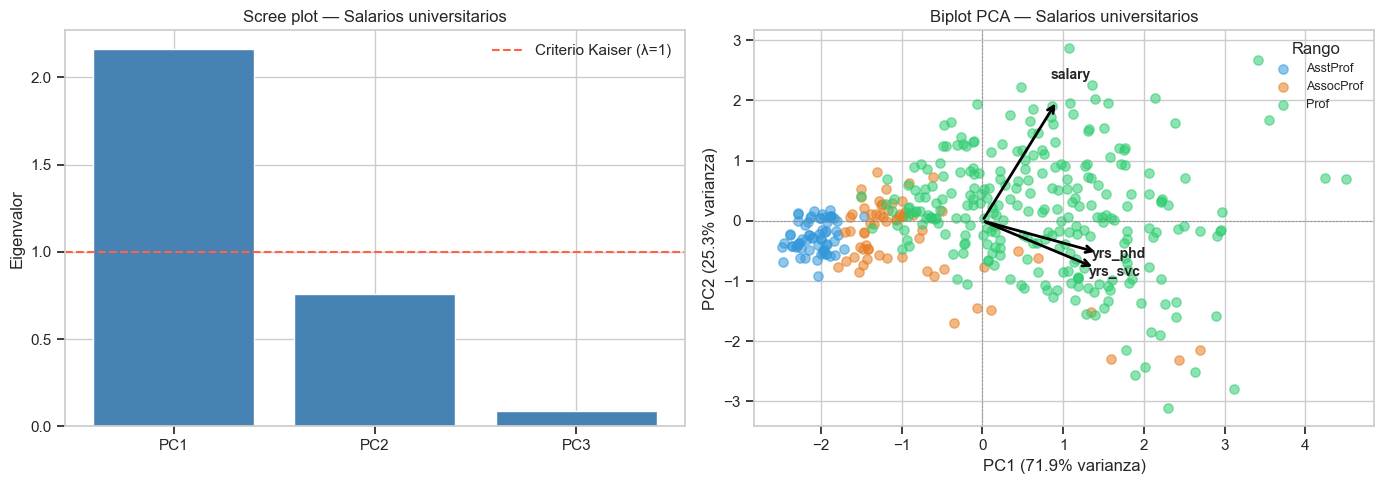

In [29]:
# Biplot coloreado por rango + Scree plot
color_map = {'AsstProf': '#3498db', 'AssocProf': '#e67e22', 'Prof': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scree plot ---
axes[0].bar(range(1, 4), ev_sal, color='steelblue', edgecolor='white')
axes[0].axhline(1, color='tomato', linestyle='--', label='Criterio Kaiser (\u03bb=1)')
axes[0].set_xticks(range(1, 4))
axes[0].set_xticklabels(['PC1', 'PC2', 'PC3'])
axes[0].set_ylabel('Eigenvalor')
axes[0].set_title('Scree plot \u2014 Salarios universitarios')
axes[0].legend()

# --- Biplot PC1 vs PC2 ---
for rk, col in color_map.items():
    mask = sal['rank'] == rk
    axes[1].scatter(Z_sal[mask, 0], Z_sal[mask, 1],
                    c=col, label=rk, alpha=0.55, s=45)

escl = 2.2
load2_sal = pca_sal.components_[:2].T
for i, var in enumerate(vars_num):
    axes[1].annotate('', xy=(load2_sal[i,0]*escl, load2_sal[i,1]*escl),
                     xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color='black', lw=2))
    axes[1].text(load2_sal[i,0]*escl*1.18, load2_sal[i,1]*escl*1.18,
                 var, fontsize=10, fontweight='bold', ha='center')

axes[1].axhline(0, color='gray', lw=0.5, linestyle='--')
axes[1].axvline(0, color='gray', lw=0.5, linestyle='--')
axes[1].set_xlabel(f'PC1 ({pve_sal[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({pve_sal[1]*100:.1f}% varianza)')
axes[1].set_title('Biplot PCA \u2014 Salarios universitarios')
axes[1].legend(title='Rango', fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
# ANOVA de los scores del PCA por rango
df_sal_scores = pd.DataFrame(Z_sal, columns=['PC1','PC2','PC3'])
df_sal_scores['rank'] = sal['rank'].values

print('ANOVA de las puntuaciones del PCA por rango acad\u00e9mico')
print('='*55)
for pc in ['PC1','PC2','PC3']:
    grps = [df_sal_scores.loc[df_sal_scores['rank']==r, pc] for r in orden_rank]
    F, p = f_oneway(*grps)
    grand = df_sal_scores[pc].mean()
    sce = sum(len(g)*(g.mean()-grand)**2 for g in grps)
    sct = ((df_sal_scores[pc]-grand)**2).sum()
    eta2_pc = sce/sct
    sig = '\u2714 Significativa' if p < 0.05 else '\u2718 No significativa'
    print(f'  {pc}: F={F:7.2f}, p={p:.4f}, \u03b7\u00b2={eta2_pc:.3f}  \u2192 {sig}')

ANOVA de las puntuaciones del PCA por rango académico
  PC1: F= 255.21, p=0.0000, η²=0.564  → ✔ Significativa
  PC2: F=  10.67, p=0.0000, η²=0.051  → ✔ Significativa
  PC3: F=   3.42, p=0.0337, η²=0.017  → ✔ Significativa


### 3.4 Interpretación integrada

| Resultado | Hallazgo |
|---|---|
| ANOVA one-way (rango) | El rango explica una fracción significativa de la varianza salarial (η² ≈ 0.33) |
| ANOVA two-way (rango × disciplina) | El efecto principal del rango domina; la interacción no es significativa |
| Tukey HSD | Todos los pares de rangos difieren significativamente en salario |
| PCA | PC1 captura la mayor parte de la varianza y refleja «seniority» (carga positiva en yrs_phd, yrs_svc y salary) |
| ANOVA sobre PC1 | PC1 discrimina fuertemente por rango (η² elevado) |
| PC2 | Captura la tensión entre años de servicio y salario; discrimina menos entre rangos |

> **Conclusión**: El PCA revela que los salarios siguen una trayectoria unidimensional de seniority. El ANOVA confirma que esa trayectoria se mapea directamente al rango académico, con diferencias estadísticamente significativas entre todos los pares de categorías.

---
## Resumen y puntos clave

### ANOVA
- Descompone la varianza total en varianza **entre grupos** (explicada) y **dentro de grupos** (error).
- La razón $F = \text{CME}/\text{CMD}$ mide cuánto mayor es la variabilidad entre grupos respecto al ruido.
- Los supuestos son normalidad de residuos, homocedasticidad e independencia.
- Cuando se rechaza $H_0$, las pruebas post-hoc (Tukey, Bonferroni) identifican qué pares difieren.

### PCA como extensión
- PCA busca las **direcciones de máxima varianza** en el espacio $p$-dimensional.
- Los eigenvalores $\lambda_j$ cumplen el mismo rol que SCE/SCT en ANOVA: cuantifican la «importancia» de cada componente.
- El **scree plot** es el análogo visual de la tabla ANOVA.
- Las cargas (loadings) revelan qué variables originales explican cada componente.
- El biplot combina la posición de muestras y variables en el espacio reducido.

### Conexión práctica
| Concepto ANOVA | Equivalente PCA |
|---|---|
| SC total ($\sum \lambda_j$) | Varianza total de los datos |
| SC entre grupos por variable | Eigenvalor $\lambda_j$ del $j$-ésimo CP |
| $\eta^2 = \text{SCE}/\text{SCT}$ | PVE$_j = \lambda_j / \sum \lambda$ |
| Factor (variable categórica) | Componente principal (combinación lineal) |
| Grado de libertad | Dimensión capturada |

> **El PCA extiende la lógica de ANOVA del espacio univariado al multivariado: en lugar de preguntar "¿cuánto explica el grupo?", pregunta "¿cuánto explica esta dirección del espacio?".**